In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'src'))

from data_preprocessing import (
    DEFAULT_FAILURE_EVENTS,
    default_feature_cols,
    label_split_and_save,
    load_metropt3,
    numeric_distribution_summary,
    filter_by_date_range,
)

In [2]:
DATA_PATH = PROJECT_ROOT / 'dataset' / 'MetroPT3(AirCompressor).csv'
PREPROCESSED_ROOT = PROJECT_ROOT / 'dataset' / 'preprocessed'

# Explicit split ranges.
TRAIN_START = '2020-02-01 00:00:00'
TRAIN_END = '2020-04-01 00:00:00'
VAL_START = '2020-04-01 00:00:00'
VAL_END = '2020-05-01 00:00:00'
TEST_START = '2020-05-01 00:00:00'
TEST_END = '2020-07-01 00:00:00'

# Plot only a fraction of the rows for a faster anomaly-vs-normal comparison.
PLOT_SAMPLE_FRACTION = 0.7
PLOT_MAX_FEATURES = 6
PLOT_RANDOM_SEED = 42

FAILURE_EVENTS = DEFAULT_FAILURE_EVENTS

artifacts = label_split_and_save(
    csv_path=DATA_PATH,
    preprocessed_root=PREPROCESSED_ROOT,
    timestamp_col='timestamp',
    failure_events=FAILURE_EVENTS,
    train_start=TRAIN_START,
    train_end=TRAIN_END,
    val_start=VAL_START,
    val_end=VAL_END,
    test_start=TEST_START,
    test_end=TEST_END,
)

labeled_df = load_metropt3(artifacts.labeled_csv_path)
labeled_df = filter_by_date_range(labeled_df, timestamp_col='timestamp', data_start=TRAIN_START, data_end=TEST_END)

print(f'Dataset path: {DATA_PATH}')
print(f'Rows in selected range: {len(labeled_df):,}')
print(f'Columns: {labeled_df.shape[1]}')
print('Original CSV was updated in place with failure labels.')
print(f'Preprocessed root: {artifacts.preprocessed_root}')
print(f'Split run directory: {artifacts.split_dir}')
print(f'Train split: {artifacts.train_csv_path}')
print(f'Val split: {artifacts.val_csv_path}')
print(f'Test split: {artifacts.test_csv_path}')

Dataset path: /Users/Leviathan/Downloads/DDA4210/vae-anomaly-detector/dataset/MetroPT3(AirCompressor).csv
Rows in selected range: 1,073,346
Columns: 19
Original CSV was updated in place with failure labels.
Preprocessed root: /Users/Leviathan/Downloads/DDA4210/vae-anomaly-detector/dataset/preprocessed
Split run directory: /Users/Leviathan/Downloads/DDA4210/vae-anomaly-detector/dataset/preprocessed/splits/20260422_161847
Train split: /Users/Leviathan/Downloads/DDA4210/vae-anomaly-detector/dataset/preprocessed/splits/20260422_161847/train_split.csv
Val split: /Users/Leviathan/Downloads/DDA4210/vae-anomaly-detector/dataset/preprocessed/splits/20260422_161847/val_split.csv
Test split: /Users/Leviathan/Downloads/DDA4210/vae-anomaly-detector/dataset/preprocessed/splits/20260422_161847/test_split.csv


In [3]:
df = labeled_df
train_df = load_metropt3(artifacts.train_csv_path)
val_df = load_metropt3(artifacts.val_csv_path)
test_df = load_metropt3(artifacts.test_csv_path)
feature_cols = default_feature_cols(df, timestamp_col='timestamp')

print(f'Feature count: {len(feature_cols)}')
print('Features:')
for c in feature_cols:
    print(f' - {c}')

print('\nSplit periods:')
print(f' - Train start: {train_df["timestamp"].min()}')
print(f' - Train end:   {train_df["timestamp"].max()}')
print(f' - Val start:   {val_df["timestamp"].min()}')
print(f' - Val end:     {val_df["timestamp"].max()}')
print(f' - Test start:  {test_df["timestamp"].min()}')
print(f' - Test end:    {test_df["timestamp"].max()}')
print(f' - Train rows:  {len(train_df):,}')
print(f' - Val rows:    {len(val_df):,}')
print(f' - Test rows:   {len(test_df):,}')

Feature count: 15
Features:
 - TP2
 - TP3
 - H1
 - DV_pressure
 - Reservoirs
 - Oil_temperature
 - Motor_current
 - COMP
 - DV_eletric
 - Towers
 - MPG
 - LPS
 - Pressure_switch
 - Oil_level
 - Caudal_impulses

Split periods:
 - Train start: 2020-02-01 00:00:00
 - Train end:   2020-03-31 23:59:59
 - Val start:   2020-04-01 00:00:09
 - Val end:     2020-04-30 23:39:23
 - Test start:  2020-05-01 12:33:38
 - Test end:    2020-06-30 23:59:58
 - Train rows:  445,298
 - Val rows:    198,734
 - Test rows:   429,314


In [4]:
def failure_proportion_table(x):
    counts = x['failure_label'].value_counts(dropna=False).sort_index()
    labels = pd.Index([0, 1], dtype='int64')
    counts = counts.reindex(labels, fill_value=0)
    out = pd.DataFrame({
        'count': counts.values,
        'proportion': (counts.values / len(x)) if len(x) else [0.0, 0.0],
    }, index=['non_failure(0)', 'failure(1)'])
    return out

train_failure_prop = failure_proportion_table(train_df)
val_failure_prop = failure_proportion_table(val_df)
test_failure_prop = failure_proportion_table(test_df)

print('Train failure/non-failure summary')
display(train_failure_prop)

print('Val failure/non-failure summary')
display(val_failure_prop)

print('Test failure/non-failure summary')
display(test_failure_prop)

Train failure/non-failure summary


,count,proportion
non_failure(0),445298,1.0
failure(1),0,0.0


Val failure/non-failure summary


,count,proportion
non_failure(0),190077,0.956439
failure(1),8657,0.043561


Test failure/non-failure summary


,count,proportion
non_failure(0),409639,0.954171
failure(1),19675,0.045829


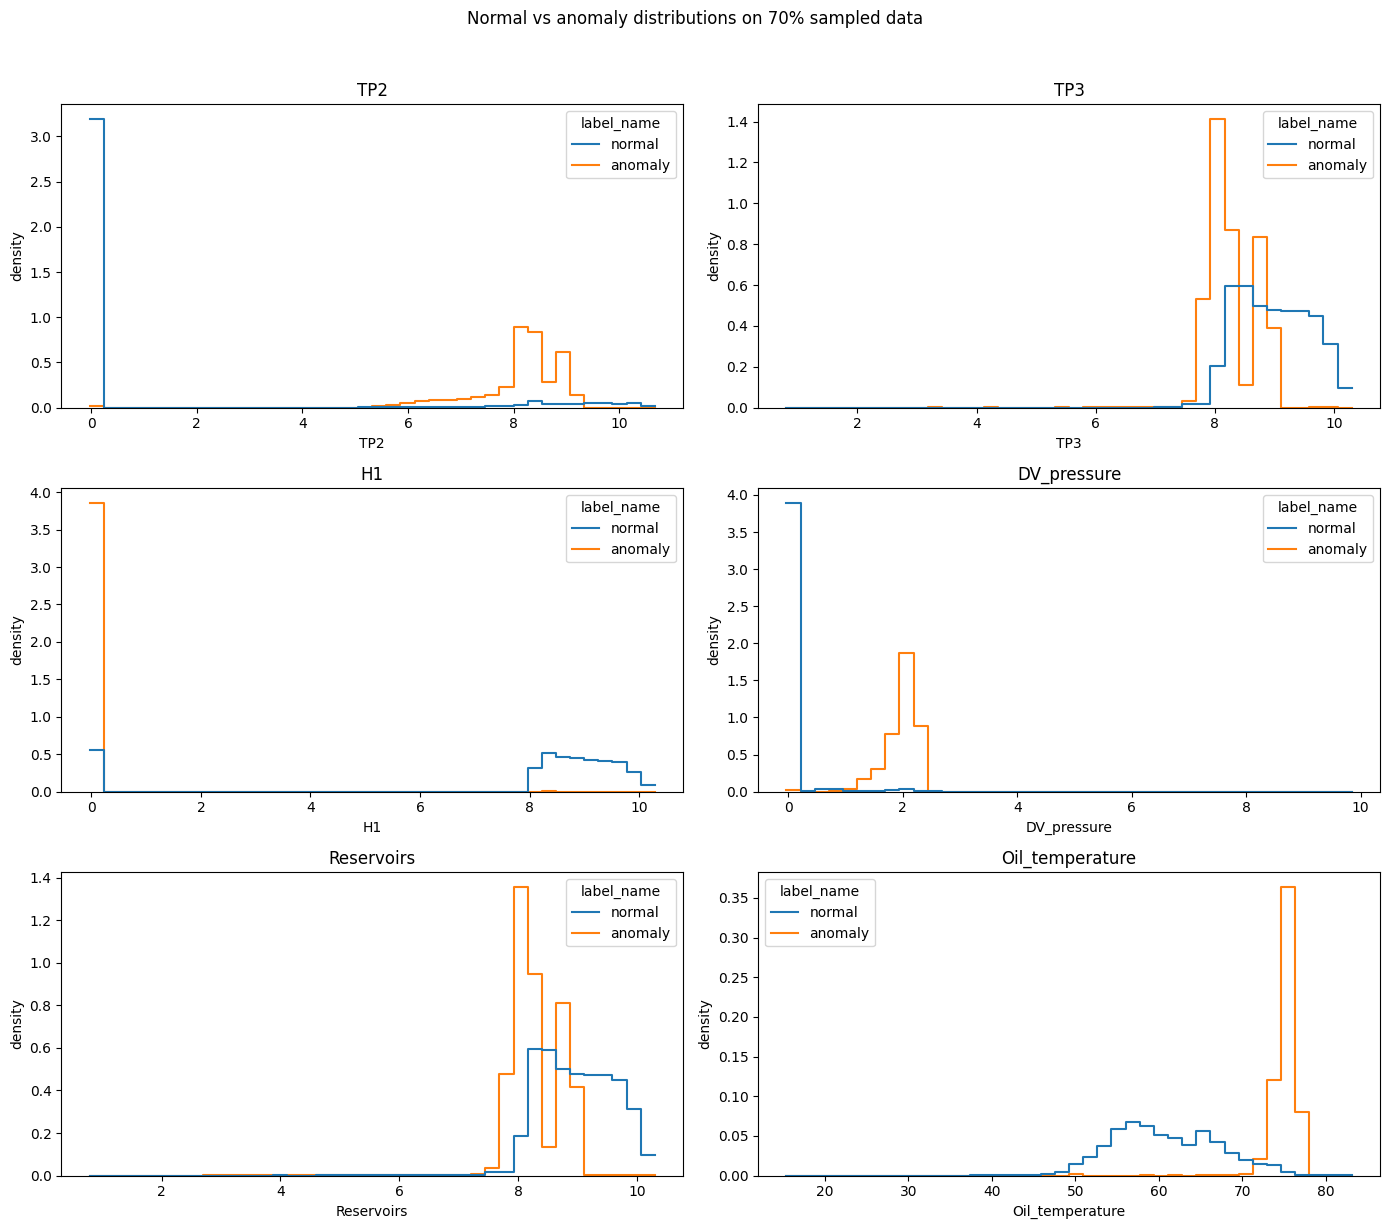

In [5]:
def _sample_for_plotting(x, frac, seed):
    if len(x) == 0:
        return x
    frac = max(0.0, min(1.0, float(frac)))
    if frac >= 1.0:
        return x
    return x.sample(frac=frac, random_state=seed)

def plot_normal_vs_anomaly_distributions(df, feature_cols, sample_frac=0.7, max_features=6, seed=42):
    sampled_parts = []
    for _, group in df.groupby('failure_label'):
        sampled_parts.append(_sample_for_plotting(group, sample_frac, seed))
    plot_df = pd.concat(sampled_parts, ignore_index=True) if sampled_parts else df.copy()
    plot_df = plot_df.assign(label_name=plot_df['failure_label'].map({0: 'normal', 1: 'anomaly'}))
    plot_features = list(feature_cols)[:max_features]
    if len(plot_features) == 0:
        print('No numeric features available for plotting.')
        return
    n_cols = 2
    n_rows = (len(plot_features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, feature in zip(axes, plot_features):
        sns.histplot(
            data=plot_df,
            x=feature,
            hue='label_name',
            stat='density',
            common_norm=False,
            bins=40,
            element='step',
            fill=False,
            ax=ax,
        )
        ax.set_title(feature)
        ax.set_xlabel(feature)
        ax.set_ylabel('density')
    for ax in axes[len(plot_features):]:
        ax.axis('off')
    fig.suptitle(f'Normal vs anomaly distributions on {sample_frac:.0%} sampled data', y=1.02)
    plt.tight_layout()
    plt.show()

plot_normal_vs_anomaly_distributions(
    labeled_df,
    feature_cols,
    sample_frac=PLOT_SAMPLE_FRACTION,
    max_features=PLOT_MAX_FEATURES,
    seed=PLOT_RANDOM_SEED,
)

In [6]:
train_stats = numeric_distribution_summary(train_df, feature_cols)
test_stats = numeric_distribution_summary(test_df, feature_cols)

print('Train distribution stats (min, p10, median, p90, mean, std, max)')
display(train_stats.round(4))

print('Test distribution stats (min, p10, median, p90, mean, std, max)')
display(test_stats.round(4))

Train distribution stats (min, p10, median, p90, mean, std, max)


,min,p10,median,p90,mean,std,max
COMP,0.000,0.000,1.0000,1.0000,0.8817,0.3230,1.000
Caudal_impulses,0.000,0.000,1.0000,1.0000,0.8230,0.3817,1.000
DV_eletric,0.000,0.000,0.0000,1.0000,0.1185,0.3232,1.000
DV_pressure,-0.032,-0.026,-0.0220,-0.0140,0.0084,0.1713,6.530
H1,-0.034,-0.008,8.8340,9.7380,7.9198,2.9538,10.272
LPS,0.000,0.000,0.0000,0.0000,0.0012,0.0351,1.000
MPG,0.000,0.000,1.0000,1.0000,0.8814,0.3233,1.000
Motor_current,0.020,0.035,0.0425,5.5825,1.6778,2.2106,9.295
Oil_level,0.000,1.000,1.0000,1.0000,0.9979,0.0462,1.000
Oil_temperature,15.400,52.575,58.0500,68.4000,59.3432,6.3580,83.125


Test distribution stats (min, p10, median, p90, mean, std, max)


,min,p10,median,p90,mean,std,max
COMP,0.000,0.000,1.0000,1.000,0.7674,0.4225,1.000
Caudal_impulses,0.000,1.000,1.0000,1.000,0.9834,0.1278,1.000
DV_eletric,0.000,0.000,0.0000,1.000,0.2160,0.4115,1.000
DV_pressure,-0.030,-0.024,-0.0200,-0.014,0.1471,0.5713,7.874
H1,-0.036,-0.012,8.6520,9.732,6.9582,3.7846,10.288
LPS,0.000,0.000,0.0000,0.000,0.0040,0.0628,1.000
MPG,0.000,0.000,1.0000,1.000,0.7674,0.4225,1.000
Motor_current,0.020,0.040,3.5475,5.630,2.3530,2.3875,9.270
Oil_level,0.000,1.000,1.0000,1.000,0.9834,0.1278,1.000
Oil_temperature,20.600,55.900,64.6000,71.975,63.9909,5.9810,80.225


In [7]:
print('Failure label counts (full dataset):')
display(df['failure_label'].value_counts(dropna=False).rename('count').to_frame())

print('Failure windows in use:')
display(pd.DataFrame(FAILURE_EVENTS))

Failure label counts (full dataset):


,count
failure_label,
0,1045014
1,28332


Failure windows in use:


,id,start,end,failure_type
0,F1,2020-04-18 00:00:00,2020-04-18 23:59:00,AirLeak
1,F2,2020-05-29 23:30:00,2020-05-30 06:00:00,AirLeak
2,F3,2020-06-05 10:00:00,2020-06-07 14:30:00,AirLeak
3,F4,2020-07-15 14:30:00,2020-07-15 19:00:00,AirLeak
